In [1]:
import pandas as pd

In [2]:
#Dicionário de dados:
data_dict_simplificado = {
    "Team_Name": ["Borussia Dortmund", "Nottingham Forest", "Aston Villa", "Marseille"],
    "Year_Championship": [1997, 1979, 1982, 1993],
    "Goals_Scored": [19, 17, 14, 16],  # Exemplos de gols marcados na campanha
    "Goals_Conceded": [7, 7, 6, 11],  # Exemplos de gols sofridos na campanha
    "Matches_Played": [11, 9, 9, 12],  # Total de jogos disputados
    "Top_Scorer_Goals": [5, 3, 3, 7],  # Gols marcados pelo principal goleador
    "Group_Stage_Ranking": [1, 1, 1, 1],  # Posição na fase de grupos
    "Possession_Avg": [52.3, 48.5, 49.9, 53.7],  # Média de posse de bola em %
}

In [3]:
underdogs = pd.DataFrame(data_dict_simplificado)

In [4]:
underdogs

,Team_Name,Year_Championship,Goals_Scored,Goals_Conceded,Matches_Played,Top_Scorer_Goals,Group_Stage_Ranking,Possession_Avg
0,Borussia Dortmund,1997,19,7,11,5,1,52.3
1,Nottingham Forest,1979,17,7,9,3,1,48.5
2,Aston Villa,1982,14,6,9,3,1,49.9
3,Marseille,1993,16,11,12,7,1,53.7


## Análise de Eficiência Ofensiva e Defensiva:

#### Compare a relação entre a eficiência ofensiva (número de gols marcados) e a eficiência defensiva (número de gols sofridos) dos campeões improváveis da Liga dos Campeões.

#### Existe uma correlação entre um time ter uma defesa sólida (baixo número de gols sofridos) e um ataque eficiente (alto número de gols marcados) para os campeões improváveis da competição?

In [5]:
underdogs['Good_Def'] = underdogs['Goals_Scored'] - underdogs['Goals_Conceded']

In [6]:
underdogs

,Team_Name,Year_Championship,Goals_Scored,Goals_Conceded,Matches_Played,Top_Scorer_Goals,Group_Stage_Ranking,Possession_Avg,Good_Def
0,Borussia Dortmund,1997,19,7,11,5,1,52.3,12
1,Nottingham Forest,1979,17,7,9,3,1,48.5,10
2,Aston Villa,1982,14,6,9,3,1,49.9,8
3,Marseille,1993,16,11,12,7,1,53.7,5


In [7]:
correlacao = underdogs['Goals_Scored'].corr(underdogs['Good_Def'])
print(f'Existe uma correlação de {round(correlacao, 2)} entre gols marcados e sofridos. Logo, moderadamente forte.')

Existe uma correlação de 0.67 entre gols marcados e sofridos. Logo, moderadamente forte.


## Relação entre Posse de Bola e Desempenho na Fase de Grupos:

#### Examine a relação entre a média de posse de bola (Possession_Avg) e o desempenho na fase de grupos (Group_Stage_Ranking).

#### Times com maior média de posse de bola tendem a se classificar melhor na fase de grupos? Ou seja, existe uma correlação entre a posse de bola e o desempenho na fase inicial da competição?

In [24]:
import matplotlib.pyplot as plt

In [25]:
import seaborn as sns

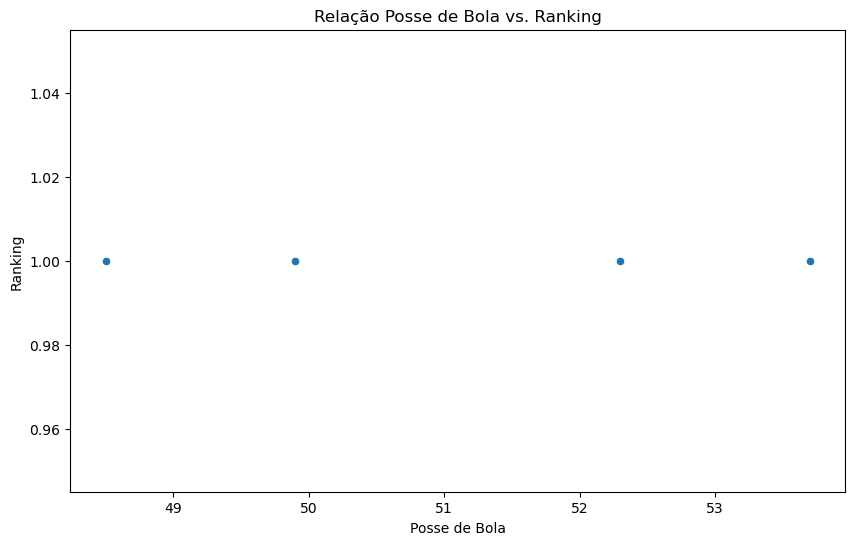

In [34]:
ax = plt.figure(figsize = (10, 6))
ax = sns.scatterplot(data = underdogs, x = 'Possession_Avg', y = 'Group_Stage_Ranking' )
ax = plt.title('Relação Posse de Bola vs. Ranking')
ax = plt.xlabel('Posse de Bola')
ax = plt.ylabel('Ranking')


ax = plt.show()

In [35]:
#Análise gráfica se fez necessária, visto que as medidas de correlação não funcionam muito bem com valores constantes ou muito próximo
#ou ainda com uma amostra pequena. Ou a quantidade de dados é baixa, ou não há indícios de que a posse de bola unfluencie no rankeamento das equipes

## Análise de Desempenho Médio por Time:

#### Calcule o desempenho médio de cada time com base em três métricas: gols marcados (Goals_Scored), gols sofridos (Goals_Conceded) e média de posse de bola (Possession_Avg):

In [36]:
underdogs

,Team_Name,Year_Championship,Goals_Scored,Goals_Conceded,Matches_Played,Top_Scorer_Goals,Group_Stage_Ranking,Possession_Avg,Good_Def
0,Borussia Dortmund,1997,19,7,11,5,1,52.3,12
1,Nottingham Forest,1979,17,7,9,3,1,48.5,10
2,Aston Villa,1982,14,6,9,3,1,49.9,8
3,Marseille,1993,16,11,12,7,1,53.7,5


#### Ordene os times com base nas médias dessas métricas:

#### Crie um gráfico de barras para visualizar e comparar os desempenhos dos times nas três métricas:

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

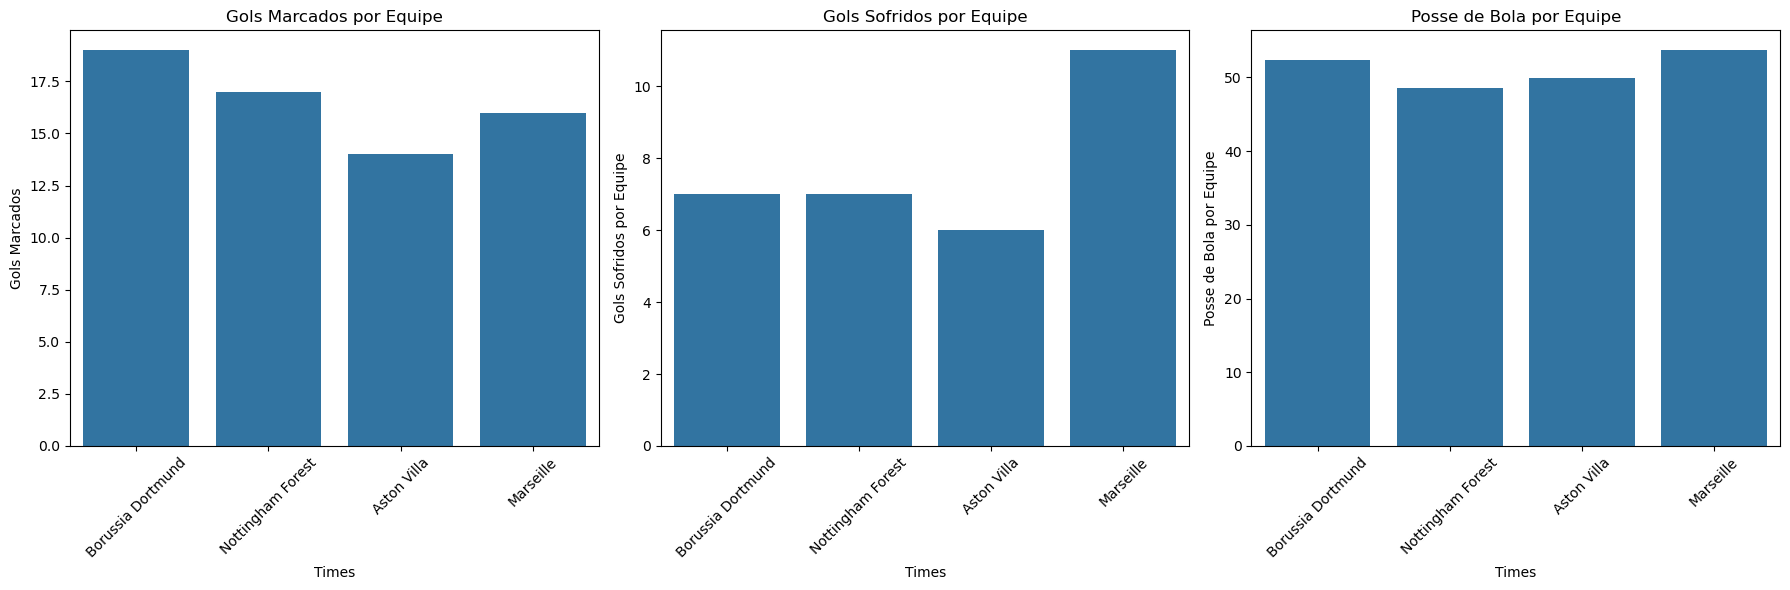

In [109]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (18, 6))

sns.barplot(data = underdogs, x = 'Team_Name', y = 'Goals_Scored', ax = axes[0])
axes[0].set_xlabel('Times')
axes[0].set_ylabel('Gols Marcados')
axes[0].set_title('Gols Marcados por Equipe')
axes[0].tick_params(axis = 'x', rotation = 45)

sns.barplot(data = underdogs, x = 'Team_Name', y = 'Goals_Conceded', ax = axes[1])
axes[1].set_xlabel('Times')
axes[1].set_ylabel('Gols Sofridos por Equipe')
axes[1].set_title('Gols Sofridos por Equipe')
axes[1].tick_params(axis = 'x', rotation  = 45)

sns.barplot(data = underdogs, x = 'Team_Name', y = 'Possession_Avg', ax = axes[2])
axes[2].set_xlabel('Times')
axes[2].set_ylabel('Posse de Bola por Equipe')
axes[2].set_title('Posse de Bola por Equipe')
axes[2].tick_params(axis = 'x', rotation  = 45)

plt.tight_layout()
plt.show()